In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [12]:
sequence = np.array(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))

print(sequence)

['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [13]:
window_size = 3

# X = inputs/questions
# y = correct answers

X = []
y = []

for i in range(len(sequence) - window_size):
    X.append(sequence[i:i + window_size])
    y.append(sequence[i + window_size])

print("First 5 input examples:")
print(X[:5])

print("First 5 answers:")
print(y[:5])

First 5 input examples:
[array(['A', 'B', 'C'], dtype='<U1'), array(['B', 'C', 'D'], dtype='<U1'), array(['C', 'D', 'E'], dtype='<U1'), array(['D', 'E', 'F'], dtype='<U1'), array(['E', 'F', 'G'], dtype='<U1')]
First 5 answers:
[np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H')]


In [14]:
letter_to_int = {
    letter: i for i, letter in enumerate(sequence)
}

print("Letter to number:")
print(letter_to_int)

Letter to number:
{np.str_('A'): 0, np.str_('B'): 1, np.str_('C'): 2, np.str_('D'): 3, np.str_('E'): 4, np.str_('F'): 5, np.str_('G'): 6, np.str_('H'): 7, np.str_('I'): 8, np.str_('J'): 9, np.str_('K'): 10, np.str_('L'): 11, np.str_('M'): 12, np.str_('N'): 13, np.str_('O'): 14, np.str_('P'): 15, np.str_('Q'): 16, np.str_('R'): 17, np.str_('S'): 18, np.str_('T'): 19, np.str_('U'): 20, np.str_('V'): 21, np.str_('W'): 22, np.str_('X'): 23, np.str_('Y'): 24, np.str_('Z'): 25}


In [15]:
X_numeric = []
y_numeric = []

for inputs, answer in zip(X, y):
    X_numeric.append([letter_to_int[letter] for letter in inputs])
    y_numeric.append(letter_to_int[answer])

X_numeric = np.array(X_numeric)
y_numeric = np.array(y_numeric)

print("X numeric:")
print(X_numeric[:5])

print("y numeric:")
print(y_numeric[:5])

X numeric:
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]]
y numeric:
[3 4 5 6 7]


In [16]:
X_numeric = X_numeric.reshape(
    (X_numeric.shape[0], X_numeric.shape[1], 1)
)

print("New X shape:", X_numeric.shape)

New X shape: (23, 3, 1)


In [17]:
model = Sequential()

model.add(
    SimpleRNN(
        50,
        activation='relu',
        input_shape=(window_size, 1)
    )
)

model.add(Dense(1))

print("Model created successfully!")

Model created successfully!


In [18]:
model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_numeric,
    y_numeric,
    epochs=500,
    verbose=0
)

print("Training complete.")

Training complete.


In [20]:
test_input = np.array([
    letter_to_int["H"],
    letter_to_int["I"],
    letter_to_int["J"]
])

# RNN expects: samples, timesteps, features
test_input = test_input.reshape((1, window_size, 1))

predicted = model.predict(test_input, verbose=0)

# Convert predicted number back to a letter
predicted_number = round(predicted[0][0])

predicted_letter = sequence[predicted_number]

print("Input:", ["H", "I", "J"])
print("Predicted next letter:", predicted_letter)

Input: ['H', 'I', 'J']
Predicted next letter: K


In [21]:
predictions = model.predict(X_numeric, verbose=0)

predicted_letters = []

for prediction in predictions:
    predicted_number = round(prediction[0])
    predicted_letter = sequence[predicted_number]
    predicted_letters.append(predicted_letter)

print("True letters:")
print(y)

print("Predicted letters:")
print(predicted_letters)

True letters:
[np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]
Predicted letters:
[np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]


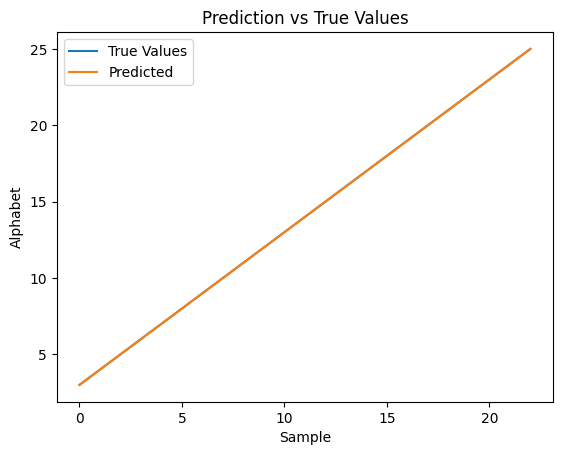

In [22]:
plt.plot(
    [letter_to_int[letter] for letter in y],
    label='True Values'
)

plt.plot(
    [letter_to_int[letter] for letter in predicted_letters],
    label='Predicted'
)

plt.legend()
plt.title("Prediction vs True Values")
plt.xlabel("Sample")
plt.ylabel("Alphabet")
plt.show()